<h1>DCGAN Model</h1>

In [88]:
import numpy as np
from sklearn.model_selection import train_test_split
from collections import defaultdict
import os
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import time
from scipy.linalg import sqrtm
from tensorflow.keras.applications import InceptionV3
import shutil
from tensorflow.keras.preprocessing import image_dataset_from_directory

**creating val set**

In [89]:
def create_val_split(data_dir="sampled/64_pix/split_photos_64", val_size=0.1):
    val_path = f"{data_dir}/val"
    if os.path.exists(val_path) and os.listdir(val_path):
        print("Validation set already exists. Skipping creation.")
        return
    
    for class_name in os.listdir(f"{data_dir}/train"):
        # Create class directories in val
        os.makedirs(f"{data_dir}/val/{class_name}", exist_ok=True)
        
        # Get all images for this class
        class_dir = f"{data_dir}/train/{class_name}"
        images = [f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.png'))]
        
        # Split into train/val
        train_imgs, val_imgs = train_test_split(images, test_size=val_size, random_state=42)
        
        # Move validation images
        for img in val_imgs:
            src = f"{class_dir}/{img}"
            dst = f"{data_dir}/val/{class_name}/{img}"
            shutil.move(src, dst)

# Execute before creating datasets
create_val_split()

Validation set already exists. Skipping creation.


In [90]:
# Configuration (same as before)
DATA_DIR = "sampled/64_pix/split_photos_64"
BATCH_SIZE = 64
IMG_SIZE = 64

In [91]:
# Create datasets
train_dataset = image_dataset_from_directory(
    f"{DATA_DIR}/train",
    label_mode=None,  # GANs don't need labels
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
).map(lambda x: (x / 127.5) - 1)  # Normalize to [-1, 1]

val_dataset = image_dataset_from_directory(
    f"{DATA_DIR}/val",  # Now exists after create_val_split()
    label_mode=None,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
).map(lambda x: (x / 127.5) - 1)

test_dataset = image_dataset_from_directory(
    f"{DATA_DIR}/test",
    label_mode=None,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
).map(lambda x: (x / 127.5) - 1)

# Add augmentation only to training set
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal")
])
train_dataset = train_dataset.map(lambda x: augmentation(x))

# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

Found 64031 files belonging to 1 classes.
Found 7117 files belonging to 1 classes.
Found 7907 files belonging to 1 classes.


In [132]:
total_train_images = len(train_dataset) * BATCH_SIZE
print("Total training images:", total_train_images)
total_test_images = len(test_dataset) * BATCH_SIZE
print("Total training images:", total_test_images)


Total training images: 64064
Total training images: 7936


Data Augmentation
Missing: Flipping/Rotation augmentation
Why needed: Prevents overfitting, improves generalization


Pixel Normalization
Missing: Scaling to [-1, 1] range
Why needed: DCGAN generators use Tanh activation (-1 to 1)

In [92]:
# Check dataset sizes
print(f"Train batches: {len(train_dataset)}")
print(f"Val batches: {len(val_dataset)}")
print(f"Test batches: {len(test_dataset)}")

# Check image shape
for batch in train_dataset.take(1):
    print("Batch shape:", batch.shape)  # Should be (64, 64, 64, 3)
    print("Value range:", batch.numpy().min(), batch.numpy().max())  # Should be ~[-1, 1]

Train batches: 1001
Val batches: 112
Test batches: 124
Batch shape: (64, 64, 64, 3)
Value range: -1.0 1.0


**Data Loaders**

In [93]:
# Check class distribution (optional)
def check_class_distribution(dataset_path):
    class_counts = {}
    for class_name in os.listdir(dataset_path):
        class_dir = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_dir):
            class_counts[class_name] = len(os.listdir(class_dir))
    return class_counts

print("\nClass distribution in training set:")
print(check_class_distribution(f"{DATA_DIR}/train"))

print("\nClass distribution in validation set:")
print(check_class_distribution(f"{DATA_DIR}/val"))

print("\nClass distribution in test set:")
print(check_class_distribution(f"{DATA_DIR}/test"))


Class distribution in training set:
{'drink': 12692, 'food': 18138, 'inside': 18161, 'outside': 15040}

Class distribution in validation set:
{'drink': 1411, 'food': 2016, 'inside': 2018, 'outside': 1672}

Class distribution in test set:
{'drink': 1567, 'food': 2240, 'inside': 2243, 'outside': 1857}


<h3>Model Building</h3>

**Generator**

Notes: need 3 channels for RGB (Conv2DTranspose(3, ...)
Using tanh  (outputs in [-1,1])

In [94]:
def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(8*8*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))
    
    model.add(layers.Reshape((8, 8, 256)))
    
    # Upsample layers
    model.add(layers.Conv2DTranspose(128, (5,5), strides=(2,2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))
    
    model.add(layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))
    
    model.add(layers.Conv2DTranspose(32, (5,5), strides=(2,2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))
    
    # Output layer - 3 channels for RGB
    model.add(layers.Conv2DTranspose(3, (5,5), strides=(1,1), padding='same', use_bias=False, activation='tanh'))
    return model

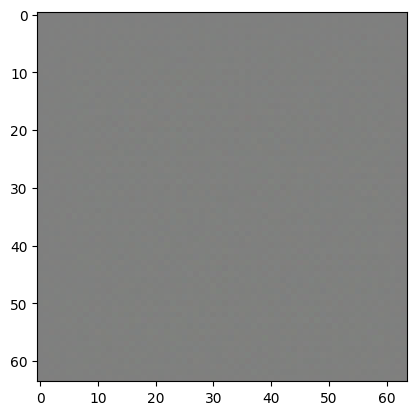

In [95]:
# Create and test generator
generator = make_generator_model()

# Generate test image
noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)

# Visualize (convert [-1,1] to [0,1])
image = (generated_image[0].numpy() + 1) / 2.0
plt.imshow(image)
plt.show()

**Discriminator**

In [96]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5,5), strides=(2,2), padding='same', 
                           input_shape=[64, 64, 3]))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5,5), strides=(2,2), padding='same'))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(256, (5,5), strides=(2,2), padding='same'))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))
    return model

In [97]:
# Build and test the discriminator model
discriminator = make_discriminator_model()

# Test with a generated image
noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)

# Pass generated image through discriminator
decision = discriminator(generated_image)
print("Discriminator decision:", decision)

# Loss functions (already defined but included for completeness)
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# Optimizers
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

Discriminator decision: tf.Tensor([[0.00052841]], shape=(1, 1), dtype=float32)


In [98]:
# After creating models
discriminator = make_discriminator_model()
noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)
decision = discriminator(generated_image)

print("Generator output shape:", generated_image.shape)
# Should be: (1, 64, 64, 3)

print("Discriminator decision shape:", decision.shape)
# Should be: (1, 1)

print("Sample decision value:", decision.numpy())
# Should be a float value like [[0.123]]

Generator output shape: (1, 64, 64, 3)
Discriminator decision shape: (1, 1)
Sample decision value: [[0.00173276]]


In [99]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

In [100]:
EPOCHS = 50
noise_dim = 100
num_examples_to_generate = 16
# to visualize progress in the animated GIF)
seed = tf.random.normal([num_examples_to_generate, noise_dim])

In [101]:
# This annotation causes the function to be "compiled".
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      generated_images = generator(noise, training=True)

      real_output = discriminator(images, training=True)
      fake_output = discriminator(generated_images, training=True)

      gen_loss = generator_loss(fake_output)
      disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

In [102]:
def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()
        
        for image_batch in dataset:
            train_step(image_batch)
        
        # Only print epoch time
        print(f"Epoch {epoch+1}/{EPOCHS} - {time.time()-start:.1f}s")
        
        # Generate samples only at the end
        if epoch == epochs - 1:
            generate_and_save_images(generator, epoch + 1, seed)
    
    print("Training complete!")
    checkpoint.save(file_prefix=checkpoint_prefix)

**Generate and save images**

In [103]:
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    
    # Rescale from [-1, 1] to [0, 1] for all channels
    predictions = (predictions + 1) / 2.0
    
    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i])  # Show RGB image
        plt.axis('off')
    
    plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
    plt.show()

In [104]:
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

Epoch 1/50 - 224.3s
Epoch 2/50 - 222.6s
Epoch 3/50 - 221.9s
Epoch 4/50 - 221.9s
Epoch 5/50 - 221.9s
Epoch 6/50 - 221.9s
Epoch 7/50 - 222.0s
Epoch 8/50 - 222.0s
Epoch 9/50 - 221.8s
Epoch 10/50 - 221.9s
Epoch 11/50 - 221.9s
Epoch 12/50 - 221.8s
Epoch 13/50 - 221.7s
Epoch 14/50 - 221.7s
Epoch 15/50 - 221.8s
Epoch 16/50 - 222.0s
Epoch 17/50 - 223.5s
Epoch 18/50 - 222.3s
Epoch 19/50 - 221.8s
Epoch 20/50 - 221.7s
Epoch 21/50 - 222.2s
Epoch 22/50 - 221.8s
Epoch 23/50 - 221.7s
Epoch 24/50 - 222.0s
Epoch 25/50 - 221.6s
Epoch 26/50 - 221.8s
Epoch 27/50 - 221.7s
Epoch 28/50 - 221.7s
Epoch 29/50 - 222.3s
Epoch 30/50 - 221.7s
Epoch 31/50 - 221.7s
Epoch 32/50 - 222.3s
Epoch 33/50 - 222.2s
Epoch 34/50 - 221.6s
Epoch 35/50 - 221.6s
Epoch 36/50 - 221.7s
Epoch 37/50 - 223.3s
Epoch 38/50 - 221.6s
Epoch 39/50 - 221.6s
Epoch 40/50 - 221.6s
Epoch 41/50 - 221.6s
Epoch 42/50 - 221.7s
Epoch 43/50 - 221.6s
Epoch 44/50 - 221.6s
Epoch 45/50 - 221.7s
Epoch 46/50 - 221.6s
Epoch 47/50 - 221.7s
Epoch 48/50 - 222.2s
E

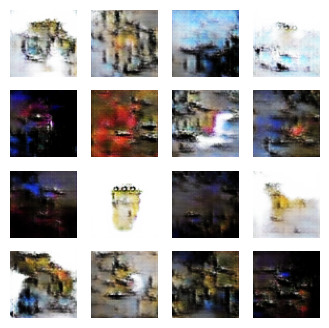

Training complete!


In [105]:
# After defining train() function:
train(train_dataset, EPOCHS)  # Use your actual dataset

In [106]:
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

**Evaluation Metrics**

In [123]:
# Add to imports
from tensorflow.keras.applications import InceptionV3
import numpy as np
from scipy.linalg import sqrtm

def calculate_inception_score(images, n_split=10, eps=1E-16, batch_size=32):
    from tensorflow.keras.applications import InceptionV3
    import numpy as np
    from scipy.special import softmax

    # Load model inside CPU scope
    with tf.device('/CPU:0'):
        inception = InceptionV3(include_top=True, weights='imagenet')

    def preprocess(imgs):
        imgs = tf.cast(imgs, tf.float32)
        imgs = tf.image.resize((imgs + 1.0) * 127.5, [299, 299])
        return imgs

    preds = []
    for i in range(0, images.shape[0], batch_size):
        batch = images[i:i+batch_size]
        batch = preprocess(batch)

        with tf.device('/CPU:0'):
            pred = inception(batch, training=False)
        pred = softmax(pred.numpy(), axis=1)  # Use softmax to convert to probs
        preds.append(pred)

    preds = np.concatenate(preds, axis=0)

    # Split into chunks
    scores = []
    for i in range(n_split):
        part = preds[i * preds.shape[0] // n_split:(i+1) * preds.shape[0] // n_split]
        p_y = np.expand_dims(np.mean(part, axis=0), 0)
        kl_div = part * (np.log(part + eps) - np.log(p_y + eps))
        score = np.exp(np.mean(np.sum(kl_div, axis=1)))
        scores.append(score)

    return np.mean(scores), np.std(scores)


def calculate_fid(real_images, gen_images, batch_size=50):
    from tensorflow.keras.applications.inception_v3 import InceptionV3
    from scipy.linalg import sqrtm

    # Load model without top layer, global average pooling
    inception = InceptionV3(include_top=False, pooling='avg', input_shape=(299, 299, 3))

    def preprocess(images):
        images = tf.cast(images, tf.float32)
        images = (images + 1.0) * 127.5  # scale to [0, 255]
        images = tf.image.resize(images, [299, 299])
        return images

    def get_activations(images):
        activations = []
        for i in range(0, images.shape[0], batch_size):
            batch = preprocess(images[i:i+batch_size])
            with tf.device('/CPU:0'):  # process on CPU to avoid OOM
                act = inception(batch, training=False)
            activations.append(act.numpy())
        return np.concatenate(activations, axis=0)

    # Compute activations
    act1 = get_activations(real_images)
    act2 = get_activations(gen_images)

    # Mean and covariance
    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)

    # FID formula
    ssdiff = np.sum((mu1 - mu2) ** 2.0)
    covmean = sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid


In [124]:
# After training
def save_sample_images(generator, num_images=5):
    noise = tf.random.normal([num_images, noise_dim])
    generated = generator(noise, training=False)
    generated = (generated + 1) / 2.0  # Convert to [0,1]
    
    for i in range(num_images):
        plt.imsave(f'dcgan_sample_{i}.png', generated[i].numpy())

# Call after training
save_sample_images(generator)

In [125]:
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

In [126]:
# Generate images for evaluation
num_eval_images = 1000
eval_noise = tf.random.normal([num_eval_images, noise_dim])
import tensorflow as tf



def generate_images_in_batches(generator, num_images=1000, batch_size=10):
    all_generated = []
    for _ in range(num_images // batch_size):
        noise = tf.random.normal([batch_size, noise_dim])
        gen_batch = generator(noise, training=False)
        all_generated.append(gen_batch)
    return tf.concat(all_generated, axis=0)

with tf.device('/CPU:0'):
    generated_images = generate_images_in_batches(generator, num_images=1000, batch_size=10)

# Load real images (use your test dataset)
real_images = []
for batch in test_dataset.take(num_eval_images // BATCH_SIZE + 1):
    real_images.append(batch)
real_images = tf.concat(real_images, axis=0)[:num_eval_images]


# Calculate metrics
is_mean, is_std = calculate_inception_score(generated_images)
fid_score = calculate_fid(real_images, generated_images)

print(f"\nEvaluation Results:")
print(f"Inception Score: {is_mean:.2f} ± {is_std:.2f}")
print(f"Fréchet Inception Distance: {fid_score:.2f}")


Evaluation Results:
Inception Score: 1.00 ± 0.00
Fréchet Inception Distance: 54396.82
